# ST2197 Coursework Project Part 2

## Part 2A

### The objective of this question is to utilize any subset of 5 consecutive years and any other supplementary information provided by Harvard Dataverse. The goal is to identify the best times and days of the week to fly to minimise delays each year.


### We import the following:
### 1. pandas - Handles data manipulation.
### 2. numpy - Supports numerical operations.
### 3. os - Used to interact with the operating system.
### 4. matplotlib.plot - Used for creating plots.
### 5. seaborn - Used for advanced visualizations.
### 6. datetime - Helps extract and format date and time information.
### 7. train_test_split from sklearn.model_selection – Splits the dataset into training and testing sets for model evaluation.
### 8. StandardScaler from sklearn.preprocessing – Standardizes numerical features by removing the mean and scaling to unit variance.
### 9. LabelEncoder from sklearn.preprocessing – Converts categorical labels into numeric format.
### 10. LogisticRegression from sklearn.linear_model – A statistical model used for binary classification tasks.

In [47]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import GridSearchCV      
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer 


# Set display options for large datasets
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


### "folder_path" defines the folder containing the data.
### "years" is a list of the needed years. 
### "file_paths" defines the identification of the files of the needed years and it is printed for verification.

In [3]:
# Define the folder path
folder_path = "./dataverse_files"

# Define the years we are using
years = [2004, 2005, 2006, 2007, 2008 ]

# Identify the Excel CSV files for these years
file_paths = {year: os.path.join(folder_path, f"{year}.csv") for year in years}

# Display identified files
print("Files to be loaded:", file_paths)


Files to be loaded: {2004: './dataverse_files\\2004.csv', 2005: './dataverse_files\\2005.csv', 2006: './dataverse_files\\2006.csv', 2007: './dataverse_files\\2007.csv', 2008: './dataverse_files\\2008.csv'}


### We will Load and store the years data from CSV files.
### We create an empty dictionary "data" to store the loaded DataFrames for each year.
### Using a for loop, we iterate through each year and file path from file_paths to read the respective CSV file. A try-except block is used to handle different file encoding. We first attempt to read the file using "UTF-8" encoding. If a "UnicodeDecodeError" occurs, we retry using "Latin-1" encoding.
### Each successfully loaded DataFrame is stored in the "data" dictionary, with the year as the key.
### After loading each file, we print the number of rows and columns for verification.
### Finally, a confirmation message is displayed once all files are successfully loaded.


In [5]:
# Empty dictionary to store the loaded DataFrames
data = {}

# Load CSV files with correct encoding
for year, file_path in file_paths.items():
    print(f"Loading {year}...")
    
    try:
        # Attempt to read with 'UTF-8'
        df = pd.read_csv(file_path, encoding="utf-8", dtype={22: str}, low_memory=False)
    except UnicodeDecodeError:
        print(f"UTF-8 failed for {year}. Retrying with latin1...")
        df = pd.read_csv(file_path, encoding="latin1", dtype={22: str}, low_memory=False)  # Alternative encoding

    # Store the DataFrame
    data[year] = df
    
    # Display basic info
    print(f"{year} loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")


print("All files loaded successfully!")

Loading 2004...
2004 loaded: 7,129,270 rows, 29 columns
Loading 2005...
2005 loaded: 7,140,596 rows, 29 columns
Loading 2006...
2006 loaded: 7,141,922 rows, 29 columns
Loading 2007...
2007 loaded: 7,453,215 rows, 29 columns
Loading 2008...
2008 loaded: 2,389,217 rows, 29 columns
All files loaded successfully!


### In addition to the yearly flight data, we load the following non-year CSV files:
### 1. "airports.csv" 
### 2. "carriers.csv" 
### 3. "plane-data.csv" 
### 4. "variable-descriptions.csv" 
### A "try-except" block is implemented to ensure successful file loading. The script first attempts to read the files using "UTF-8" encoding. If a "UnicodeDecodeError" occurs, it retries using "Latin-1" encoding.
### Once all datasets are successfully loaded, a confirmation message is displayed.


In [7]:
# Load non-year CSV files with safe encoding
try:
    airports = pd.read_csv(f"{folder_path}/airports.csv", encoding="utf-8", low_memory=False)
    carriers = pd.read_csv(f"{folder_path}/carriers.csv", encoding="utf-8", low_memory=False)
    plane_data = pd.read_csv(f"{folder_path}/plane-data.csv", encoding="utf-8", low_memory=False)
    variable_descriptions = pd.read_csv(f"{folder_path}/variable-descriptions.csv", encoding="utf-8", low_memory=False)
    
    print("All non-year datasets loaded successfully!")
    
except UnicodeDecodeError:
    print("UTF-8 failed for non-year files. Retrying with latin1...")
    airports = pd.read_csv(f"{folder_path}/airports.csv", encoding="latin1", low_memory=False)
    carriers = pd.read_csv(f"{folder_path}/carriers.csv", encoding="latin1", low_memory=False)
    plane_data = pd.read_csv(f"{folder_path}/plane-data.csv", encoding="latin1", low_memory=False)
    variable_descriptions = pd.read_csv(f"{folder_path}/variable-descriptions.csv", encoding="latin1", low_memory=False)
    
    print("All non-year datasets loaded successfully with latin1!")

All non-year datasets loaded successfully!


### We will then preview the loaded datasets.
### To verify that the data has been loaded correctly, we print the first few rows of each dataset.
### A for loop iterates through the "data" dictionary to display the first 5 rows of each yearly dataset (2004–2008).
### We also print the first 5 rows of the non-year datasets:
### 1. "airports.csv" – Displays airport-related data.
### 2. "carriers.csv" – Shows airline carrier information.
### 3. "plane-data.csv" – Contains details about aircraft.
### 4. "variable-descriptions.csv" – Provides descriptions of dataset variables.
### This will help us to see the contents of the datasets.


In [9]:
# Check the first few rows of each dataset
for year, df in data.items():
    print(f"\n{year} DATA PREVIEW:")
    print(df.head(), "\n")

# Check the non-year datasets
print("\nAIRPORTS DATA PREVIEW:")
print(airports.head())

print("\nCARRIERS DATA PREVIEW:")
print(carriers.head())

print("\nPLANE DATA PREVIEW:")
print(plane_data.head())

print("\nVARIABLE DESCRIPTIONS PREVIEW:")
print(variable_descriptions.head())



2004 DATA PREVIEW:
   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  2004      1          12          1   623.00         630   901.00   
1  2004      1          13          2   621.00         630   911.00   
2  2004      1          14          3   633.00         630   920.00   
3  2004      1          15          4   627.00         630   859.00   
4  2004      1          16          5   635.00         630   918.00   

   CRSArrTime UniqueCarrier  FlightNum TailNum  ActualElapsedTime  \
0         915            UA        462  N805UA              98.00   
1         915            UA        462  N851UA             110.00   
2         915            UA        462  N436UA             107.00   
3         915            UA        462  N828UA              92.00   
4         915            UA        462  N831UA             103.00   

   CRSElapsedTime  AirTime  ArrDelay  DepDelay Origin Dest  Distance  TaxiIn  \
0             105    80.00    -14.00     -7.00    ORD  CLT

### We will check for missing values in each dataset.
### Missing values can affect data quality and influence analysis results.
### To identify missing data, we iterate through each yearly dataset in the data dictionary using a for loop.
### For each dataset, we use "isnull().sum()" to count the number of missing values per column.
### The results are printed to help us understand which columns have missing data and whether data cleaning is necessary.

In [11]:
# check how much data is missing in each dataset
for year, df in data.items():
    print(f"\n{year} MISSING VALUES:")
    print(df.isnull().sum(), "\n")


2004 MISSING VALUES:
Year                       0
Month                      0
DayofMonth                 0
DayOfWeek                  0
DepTime               127757
CRSDepTime                 0
ArrTime               141541
CRSArrTime                 0
UniqueCarrier              0
FlightNum                  0
TailNum                  127
ActualElapsedTime     141541
CRSElapsedTime             0
AirTime               141541
ArrDelay              141541
DepDelay              127757
Origin                     0
Dest                       0
Distance                   0
TaxiIn                     0
TaxiOut                    0
Cancelled                  0
CancellationCode     7001506
Diverted                   0
CarrierDelay               0
WeatherDelay               0
NASDelay                   0
SecurityDelay              0
LateAircraftDelay          0
dtype: int64 


2005 MISSING VALUES:
Year                       0
Month                      0
DayofMonth                 0
DayOfWeek    

### A function "clean_flight_data(df)" is created to clean and preprocess flight data.
### The function performs the following cleaning steps:
### 1. Remove duplicate rows using "drop_duplicates()".
### 2. Remove canceled flights (Cancelled == 1), as they are not needed for analysis.
### 3. Drop rows with missing time-related values ("DepTime", "ArrTime", "ActualElapsedTime", "AirTime", "ArrDelay", "DepDelay"), since these are needed for analysis.
### 4. Fill missing delay-related values with 0 for columns like "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", and "LateAircraftDelay", assuming missing values indicate no delay.
### 5. Convert time columns ("DepTime", "ArrTime", "CRSDepTime", "CRSArrTime") and ensure time values are in HH:MM format by converting them using "pd.to_datetime()".
### 6. Convert categorical columns ("TailNum", "UniqueCarrier") to string format for consistency.
### This function returns a cleaned version of the dataset, ready for analysis.

In [13]:
# Function to clean flight data
def clean_flight_data(df):
    
    df_clean = df.copy()  # Create a separate copy

    # Drop duplicate rows
    df_clean.drop_duplicates(inplace=True)

    # Remove all cancelled flights (Cancelled == 1)
    df_clean = df_clean[df_clean["Cancelled"] == 0]
    
    # Drop rows where time-related values are missing
    df_clean.dropna(subset=["DepTime", "ArrTime", "ActualElapsedTime", "AirTime", "ArrDelay", "DepDelay"], inplace=True)

    # Fill missing delay-related values with 0
    delay_cols = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
    df_clean[delay_cols] = df_clean[delay_cols].fillna(0)

    # Convert time columns to HH:MM format
    time_cols = ["DepTime", "ArrTime", "CRSDepTime", "CRSArrTime"]
    for col in time_cols:
        df_clean[col] = df_clean[col].apply(lambda x: f"{int(x):04d}" if not pd.isnull(x) else None)  # Ensure four digits
        df_clean[col] = pd.to_datetime(df_clean[col], format="%H%M", errors="coerce").dt.time  # Convert to time format

    # Ensure categorical columns are strings
    df_clean["TailNum"] = df_clean["TailNum"].astype("string")
    df_clean["UniqueCarrier"] = df_clean["UniqueCarrier"].astype("string")

    return df_clean # Return the cleaned version


### We will proceed with cleaning flight data for each year.
### A new dictionary "data_clean" is created to store the cleaned versions of the flight data.
### Using a for loop, we apply the "clean_flight_data()" function to each yearly dataset in data:
### 1. The cleaned dataset for each year is stored in "data_clean[year]".
### 2. The shape (number of rows and columns) of the cleaned dataset is printed for verification.
### Once all datasets are processed, a confirmation message is displayed.
### This ensures that all flight data is cleaned and stored separately for further analysis.



In [15]:
# Clean flight data for each year

data_clean = {} # store cleaned version separately

for year in data:
    data_clean[year] = clean_flight_data(data[year])
    print(f" Cleaned {year}: {data_clean[year].shape}")

print("\n Flight data cleaned successfully!")


 Cleaned 2004: (6987721, 29)
 Cleaned 2005: (6992827, 29)
 Cleaned 2006: (7003796, 29)
 Cleaned 2007: (7275261, 29)
 Cleaned 2008: (2319117, 29)

 Flight data cleaned successfully!


### After cleaning the flight data, we preview the first 5 rows of the cleaned dataset for each year.
### Using a for loop, we iterate through "data_clean", which contains the cleaned versions of the datasets.
### The year is printed as a heading, followed by the first 5 rows of the respective cleaned dataset.
### This step helps verify that data cleaning was applied correctly.

In [17]:
# Print preview of the cleaned data for each year
for year in data_clean:
    print(f"\n {year} Cleaned Data Preview:")
    print(data_clean[year].head())  # Show first 5 rows



 2004 Cleaned Data Preview:
   Year  Month  DayofMonth  DayOfWeek   DepTime CRSDepTime   ArrTime  \
0  2004      1          12          1  06:23:00   06:30:00  09:01:00   
1  2004      1          13          2  06:21:00   06:30:00  09:11:00   
2  2004      1          14          3  06:33:00   06:30:00  09:20:00   
3  2004      1          15          4  06:27:00   06:30:00  08:59:00   
4  2004      1          16          5  06:35:00   06:30:00  09:18:00   

  CRSArrTime UniqueCarrier  FlightNum TailNum  ActualElapsedTime  \
0   09:15:00            UA        462  N805UA              98.00   
1   09:15:00            UA        462  N851UA             110.00   
2   09:15:00            UA        462  N436UA             107.00   
3   09:15:00            UA        462  N828UA              92.00   
4   09:15:00            UA        462  N831UA             103.00   

   CRSElapsedTime  AirTime  ArrDelay  DepDelay Origin Dest  Distance  TaxiIn  \
0             105    80.00    -14.00     -7.00   

### We will then clean the non-year datasets.
### The airports, carriers, and plane_data datasets are cleaned separately.
### The following cleaning steps are applied:
### 1. Cleaning the airports dataset:
### - A copy of the dataset is created to avoid modifying the original data.
### - Missing values in the "city" and "state" columns are replaced with "Unknown".
### - Duplicate rows are removed using "drop_duplicates()".
### 2. Cleaning the carriers dataset:
### - A copy of the dataset is created.
### - Rows with missing values in the "Code" column are removed.
### - Duplicate rows are dropped to avoid redundancy.
### 3. Cleaning the plane_data dataset:
### - A copy of the dataset is created.
### - Missing values in the "manufacturer" and "model" columns are replaced with "Unknown".
### - Rows with missing values in the "year" column (aircraft manufacture year) are removed.
### - Duplicate rows are dropped.
### After cleaning, a confirmation message is displayed to indicate that the non-year datasets have been successfully cleaned.

In [19]:
# Clean airports dataset
airports_clean = airports.copy()
airports_clean["city"] = airports_clean["city"].fillna("Unknown")
airports_clean["state"] = airports_clean["state"].fillna("Unknown")
airports_clean.drop_duplicates(inplace=True)  # Remove duplicates

# Clean carriers dataset
carriers_clean = carriers.copy()
carriers_clean.dropna(subset=["Code"], inplace=True)
carriers_clean.drop_duplicates(inplace=True)  # Remove duplicates


# Clean plane_data dataset
plane_data_clean = plane_data.copy()
plane_data_clean["manufacturer"] = plane_data_clean["manufacturer"].fillna("Unknown")
plane_data_clean["model"] = plane_data_clean["model"].fillna("Unknown")
plane_data_clean.dropna(subset=["year"], inplace=True)  # Drop rows where year is missing
plane_data_clean.drop_duplicates(inplace=True) # Remove duplicates

print("\n Non-year datasets cleaned successfully!")



 Non-year datasets cleaned successfully!


### After cleaning the yearly flight data, we merge all cleaned datasets into a single DataFrame, "df_all_years" for easier analysis.
### This is done using "pd.concat()", which:
### - Combines all values from "data_clean" (cleaned datasets).
### - Preserves the year as an identifier by using "keys=data_clean.keys()".
### - Assigns the multi-level index names: "Year" and "Index".
### - Uses "reset_index(drop=True)" to remove the multi-index structure and create a flat DataFrame.
### We then print the first and last 5 rows of the merged dataset to verify the structure.
### The total number of rows and columns is displayed to confirm the data was merged correctly.

In [21]:
# Merge all years' cleaned data into a single DataFrame
df_all_years = pd.concat(data_clean.values(), keys=data_clean.keys(), names=['Year', 'Index']).reset_index(drop=True)


# Print dataset preview: first 5 and last 5 rows
print(f"\nCleaned & Merged Data Preview({df_all_years.shape[0]:,} rows, {df_all_years.shape[1]} columns):")
print(pd.concat([df_all_years.head(), df_all_years.tail()]))  # Show first and last 5 rows


Cleaned & Merged Data Preview(30,578,722 rows, 29 columns):
          Year  Month  DayofMonth  DayOfWeek   DepTime CRSDepTime   ArrTime  \
0         2004      1          12          1  06:23:00   06:30:00  09:01:00   
1         2004      1          13          2  06:21:00   06:30:00  09:11:00   
2         2004      1          14          3  06:33:00   06:30:00  09:20:00   
3         2004      1          15          4  06:27:00   06:30:00  08:59:00   
4         2004      1          16          5  06:35:00   06:30:00  09:18:00   
30578717  2008      4          17          4  10:25:00   10:25:00  12:34:00   
30578718  2008      4          17          4  13:19:00   13:20:00  15:27:00   
30578719  2008      4          17          4  13:35:00   13:35:00  15:56:00   
30578720  2008      4          17          4  19:33:00   19:35:00  21:40:00   
30578721  2008      4          17          4  06:21:00   06:15:00  07:52:00   

         CRSArrTime UniqueCarrier  FlightNum TailNum  ActualElapsedTi

### We then proceed to compute "NetDelay" as the sum of Departure Delay ("DepDelay") and Arrival Delay ("ArrDelay"):
### This provides an overall measure of delay impact on flights.
### A function "time_interval(dep_time)" is created to categorize flights based on their scheduled departure time ("CRSDepTime"):
### - 00:00 - 05:59 → "Night"
### - 06:00 - 11:59 → "Morning"
### - 12:00 - 17:59 → "Afternoon"
### - 18:00 - 23:59 → "Evening"
### - If "dep_time" is missing, return "NaN".
### The function is applied to "CRSDepTime" to create a new column "TimeInterval" categorizing each flight's departure time.
### We then compute the average net delay for each time interval per year using 'groupby(["Year", "TimeInterval"])["NetDelay"].mean()'. The result is stored in "avg_delay_by_time".
### Finally, we print the computed average delays by time interval for each year.



In [23]:
# Compute Net Delay
df_all_years["NetDelay"] = df_all_years["DepDelay"] + df_all_years["ArrDelay"]

# Define time intervals
def time_interval(dep_time):
    if pd.isnull(dep_time):
        return np.nan
    hour = dep_time.hour
    if 0 <= hour < 6:
        return "00:00-05:59 (Night)"
    elif 6 <= hour < 12:
        return "06:00-11:59 (Morning)"
    elif 12 <= hour < 18:
        return "12:00-17:59 (Afternoon)"
    else:
        return "18:00-23:59 (Evening)"

df_all_years["TimeInterval"] = df_all_years["CRSDepTime"].apply(time_interval)

# Compute average net delay per time interval for each year
avg_delay_by_time = df_all_years.groupby(["Year", "TimeInterval"])["NetDelay"].mean().reset_index()

print(avg_delay_by_time)

    Year             TimeInterval  NetDelay
0   2004      00:00-05:59 (Night)      1.49
1   2004    06:00-11:59 (Morning)      5.17
2   2004  12:00-17:59 (Afternoon)     18.09
3   2004    18:00-23:59 (Evening)     25.13
4   2005      00:00-05:59 (Night)      1.69
5   2005    06:00-11:59 (Morning)      5.69
6   2005  12:00-17:59 (Afternoon)     19.74
7   2005    18:00-23:59 (Evening)     28.20
8   2006      00:00-05:59 (Night)      2.88
9   2006    06:00-11:59 (Morning)      7.55
10  2006  12:00-17:59 (Afternoon)     23.97
11  2006    18:00-23:59 (Evening)     31.25
12  2007      00:00-05:59 (Night)      5.56
13  2007    06:00-11:59 (Morning)      9.61
14  2007  12:00-17:59 (Afternoon)     27.30
15  2007    18:00-23:59 (Evening)     34.83
16  2008      00:00-05:59 (Night)      5.22
17  2008    06:00-11:59 (Morning)     11.32
18  2008  12:00-17:59 (Afternoon)     27.17
19  2008    18:00-23:59 (Evening)     32.23


### We will proceed to plot average delay by Time Interval for each year.
### We create a grouped bar plot using "sns.barplot" where:
### 1. The X-axis represents each Year.
### 2. The Y-axis shows the Average Delay in minutes.
### 3. The hue is set to "TimeInterval" so that each year contains multiple bars, one for each time interval.
### 4. The palette "tab10" is used.
### We annotate each bar with exact delay values in MM:SS format.


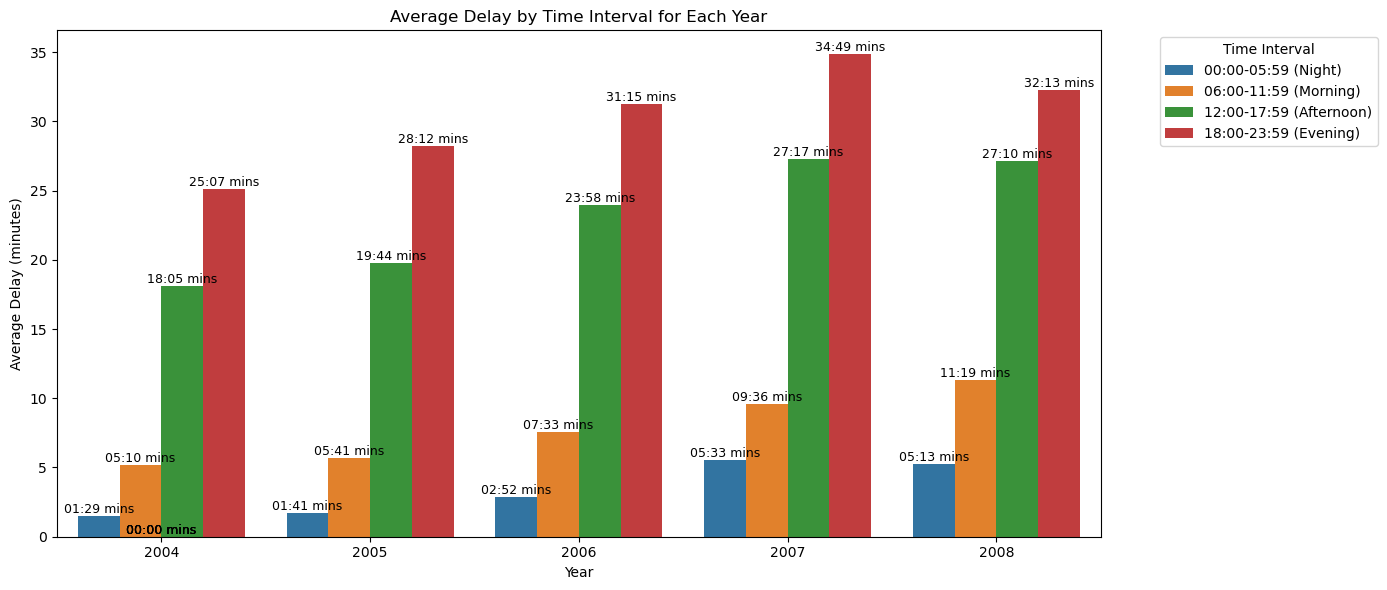

In [27]:
plt.figure(figsize=(14, 6))

# Create the bar plot with Year on x-axis and hue as TimeInterval
ax = sns.barplot(x="Year", y="NetDelay", hue="TimeInterval", data=avg_delay_by_time, palette="tab10")

# Annotate each bar with the MM:SS format
for p in ax.patches:
    total_seconds = p.get_height() * 60
    minutes = int(total_seconds // 60)
    seconds = int(total_seconds % 60)
    
    ax.annotate(f"{minutes:02}:{seconds:02} mins", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, color='black')

plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.title("Average Delay by Time Interval for Each Year")
plt.legend(title="Time Interval", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### We then determine the best time interval for each year, i.e., the time interval with the lowest average net delay and plot them in a graph.
### This is done by following these steps:
### 1. Identify the best time interval per year:
### - We use ".groupby("Year")["NetDelay"].idxmin()" to find the index of the time interval with the lowest delay for each year.
### - "avg_delay_by_time.loc[...]" extracts the corresponding rows, storing them in "best_time_per_year".
### 2. Create a bar plot to visualize the best time interval per year:
### - X-axis: Represents Year.
### - Y-axis: Represents the Average Delay (in minutes) for the best interval.
### - Hue: Displays the best time interval category for each year.
### - The "palette="Set2"" is used for distinct color representation.
### 3. Annotate bars with exact delay values:
### - Convert Net Delay (minutes) to MM:SS format.
### - Display formatted values (MM:SS mins) above each bar.
### 4. Improve plot readability:
### - Title & Labels: Clearly indicate what is being visualized.
### - Legend Placement: The legend is positioned outside the plot "(bbox_to_anchor=(1.05, 1))" to avoid clutter.
### This graph highlights the best time of day to minimize flight delays each year.


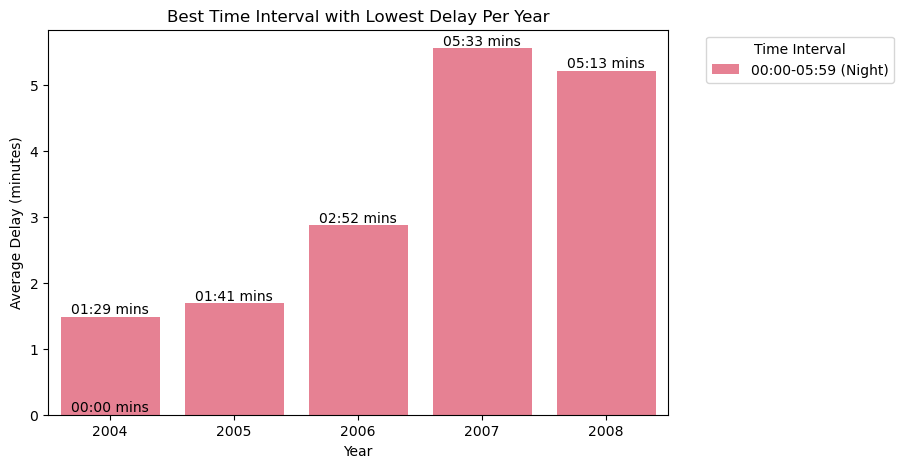

In [29]:
# Find the best interval per year (lowest average net delay)
best_time_per_year = avg_delay_by_time.loc[avg_delay_by_time.groupby("Year")["NetDelay"].idxmin()]

# Plot best time interval per year (Fixed Warning + Added Labels)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=best_time_per_year["Year"].astype(str), y=best_time_per_year["NetDelay"], hue=best_time_per_year["TimeInterval"], palette="husl")

# Add exact delay values on top of bars
for p in ax.patches:
    # Convert the net delay (in minutes) to seconds
    total_seconds = p.get_height() * 60  # Convert minutes to seconds
    minutes = int(total_seconds // 60)  # Get the minutes part
    seconds = int(total_seconds % 60)  # Get the seconds part
    
    # Annotate the bars with formatted time (MM:SS mins)
    ax.annotate(f"{minutes:02}:{seconds:02} mins",  # Format as MM:SS
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.title("Best Time Interval with Lowest Delay Per Year")
plt.legend(title="Time Interval", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("best_delay_by_time_part2a.png", dpi=300, bbox_inches='tight')
plt.show()

### We will proceed to compute Average Net Delay by day of the week for each year.
### We will group data by "Year" and "DayOfWeek", then compute the mean NetDelay for each combination and store the results in "avg_delay_by_day".
### The resulting DataFrame contains "Year", "DayOfWeek", and "NetDelay".
### We define "day_labels", storing a list of weekday names (Monday to Sunday) for reference.
### The "DayOfWeek" column in "avg_delay_by_day" contains numeric values (0 for Monday, 6 for Sunday). We map these values to their corresponding weekday names using the "day_labels" list.
### We print "avg_delay_by_day" to preview the computed values.

In [57]:
# Compute average net delay per day of the week for each year
avg_delay_by_day = df_all_years.groupby(["Year", "DayOfWeek"])["NetDelay"].mean().reset_index()


# Define labels for days of the week
day_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Convert numeric day values to actual day names using existing `day_labels`
avg_delay_by_day["DayOfWeek"] = avg_delay_by_day["DayOfWeek"].astype(int).apply(lambda x: day_labels[x-1])


print(avg_delay_by_day)

    Year  DayOfWeek  NetDelay
0   2004     Monday     16.76
1   2004    Tuesday     12.08
2   2004  Wednesday     14.23
3   2004   Thursday     16.70
4   2004     Friday     16.92
5   2004   Saturday      8.43
6   2004     Sunday     14.57
7   2005     Monday     16.98
8   2005    Tuesday     12.21
9   2005  Wednesday     15.96
10  2005   Thursday     19.82
11  2005     Friday     20.07
12  2005   Saturday      9.82
13  2005     Sunday     15.10
14  2006     Monday     19.15
15  2006    Tuesday     13.87
16  2006  Wednesday     16.85
17  2006   Thursday     23.34
18  2006     Friday     25.37
19  2006   Saturday     13.43
20  2006     Sunday     18.32
21  2007     Monday     22.38
22  2007    Tuesday     17.62
23  2007  Wednesday     20.60
24  2007   Thursday     25.53
25  2007     Friday     26.60
26  2007   Saturday     14.81
27  2007     Sunday     22.28
28  2008     Monday     22.51
29  2008    Tuesday     21.71
30  2008  Wednesday     17.12
31  2008   Thursday     21.22
32  2008  

### We will proceed to plot the graphs of Average Delay by Day of the week for each year.
### We will create a grouped bar plot using "sns.barplot" where:
### 1. The X-axis represents each Year.
### 2. The Y-axis shows the Average Delay in minutes.
### 3. The hue is set to DayOfWeek, so each year has 7 bars (one for each day), each colored differently.
### 4. The color palette "crest" is used to distinguish the days.
### We annotate each bar with exact delay values in MM:SS format.

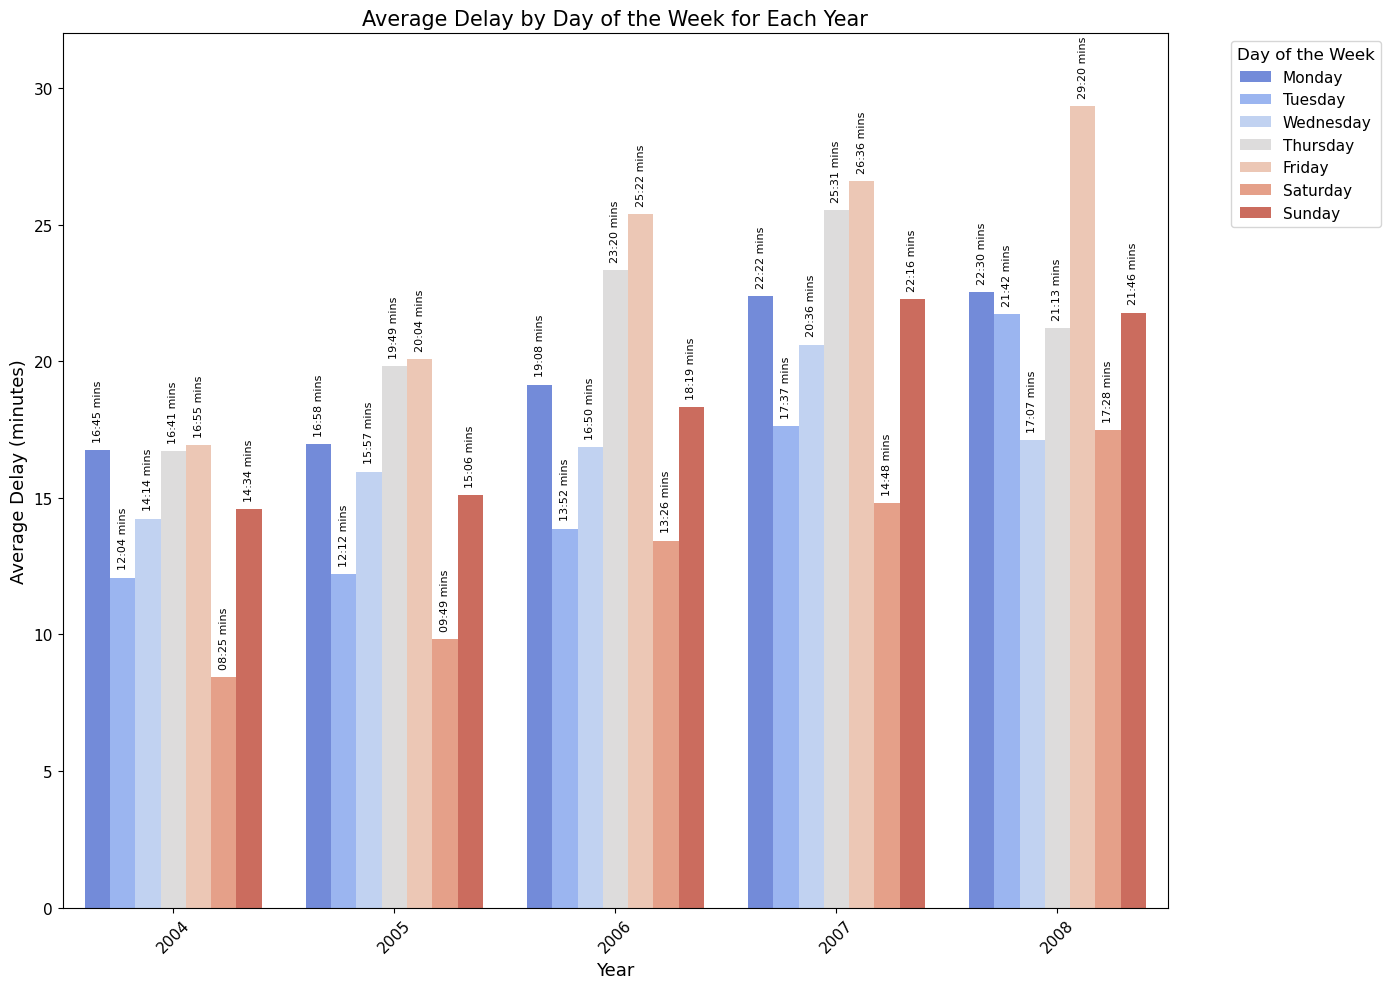

In [59]:
plt.figure(figsize=(14, 10))

# Create the grouped bar plot
ax = sns.barplot(x="Year", y="NetDelay", hue="DayOfWeek", data=avg_delay_by_day, palette="coolwarm")

plt.ylim(0,32)
# Annotate each bar with formatted MM:SS
for p in ax.patches:
    if p.get_height() > 0:
        total_seconds = p.get_height() * 60
        minutes = int(total_seconds // 60)
        seconds = int(total_seconds % 60)
        
        ax.annotate(f"{minutes:02}:{seconds:02} mins", 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), 
                    ha='center', va='bottom', fontsize=8, color='black', rotation=90)

# Customize plot aesthetics
plt.xlabel("Year", fontsize=13)
plt.ylabel("Average Delay (minutes)", fontsize=13)
plt.title("Average Delay by Day of the Week for Each Year", fontsize=15)

# Add legend for days of the week
plt.legend(title="Day of the Week", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Adjust layout and ticks
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### We then find the day with the lowest average net delay for each year by using ".groupby("Year")["NetDelay"].idxmin()" to find the index of the day with the least delay in each year. "avg_delay_by_day.loc[...]" extracts the corresponding rows, storing them in "best_day_per_year".
### We print "best_day_per_year", showing the "Year", "DayOfWeek", "NetDelay".

In [63]:
# Find the best day per year (lowest average net delay) using `avg_delay_by_day`
best_day_per_year = avg_delay_by_day.loc[avg_delay_by_day.groupby("Year")["NetDelay"].idxmin()]


print(best_day_per_year[["Year", "DayOfWeek", "NetDelay"]])

    Year  DayOfWeek  NetDelay
5   2004   Saturday      8.43
12  2005   Saturday      9.82
19  2006   Saturday     13.43
26  2007   Saturday     14.81
30  2008  Wednesday     17.12


### We will proceed to plot the Best Day with Lowest Delay per year by doing the following steps:
### 1. Create a bar plot using "Seaborn" ("sns.barplot"):
### - X-axis: Represents the Year.
### - Y-axis: Represents the Average Net Delay (in minutes) for the best day.
### - Hue: Displays the day of the week with the lowest delay for each year.
### - The palette "Set2" is used for distinct colors.
### 2. Annotate bars with exact delay values:
### - Convert Net Delay (minutes) to MM:SS format.
### - Display formatted values (MM:SS mins) above each bar.
### 3. Improve plot readability:
### - Title & Labels: Clearly indicate what is being visualized.
### Legend Placement: The legend is positioned outside the plot "(bbox_to_anchor=(1.05, 1))" to avoid clutter.


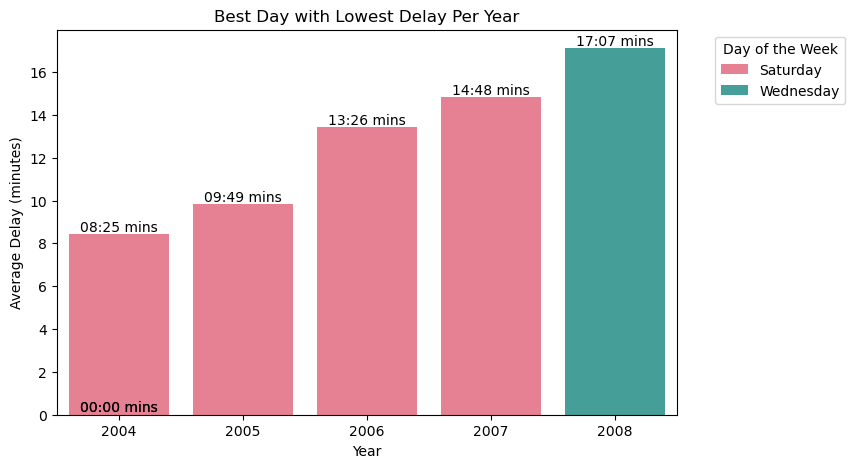

In [65]:
# Plot the best day per year
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=best_day_per_year["Year"].astype(str), y=best_day_per_year["NetDelay"], hue=best_day_per_year["DayOfWeek"], palette="husl")

# Add exact delay values on top of bars
for p in ax.patches:
    # Convert the net delay (in minutes) to minutes and seconds
    total_seconds = p.get_height() * 60  # Convert to seconds
    minutes = int(total_seconds // 60)  # Get the minutes
    seconds = int(total_seconds % 60)  # Get the seconds
    
    # Annotate the bar with the formatted time (MM:SS)
    ax.annotate(f"{minutes:02}:{seconds:02} mins", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.title("Best Day with Lowest Delay Per Year")
plt.legend(title="Day of the Week", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## End Of Part 2A
---

## Part 2B

### The objective of this question is to utilize any subset of 5 consecutive years and any other supplementary information provided by Harvard Dataverse. The goal is to determine whether older planed experience more delays on a year-to-year basis.

### We will proceed to merge flight data with Plane Data and calculate the Plane Age.
### We do this by checking if "ManufactureYear" is already present in the dataframe. If not, we merge "df_all_years" with "plane_data" to include the aircraft manufacture year, "year". This will be done using:
### - "left_on='TailNum'" (Flight data's aircraft tail number).
### - "right_on='tailnum'" (Plane data's aircraft tail number).
### We will rename the column "year" to "ManufactureYear".
### We drop the extra column tailnum after merging.
### We will calculate "PlaneAge" by minusing "ManufactureYear" from the year of flight, "Year".
### We then filter out invalid and extreme plane ages by removing negative values and unrealistic extreme values, >50.
### We then print a preview of the dataset to see.

In [71]:
# Check is manufactureYear in data else merge with plane_data
if 'ManufactureYear' not in df_all_years.columns:
    # Merge flight data with plane data to get year of manufacture for each plane
    df_all_years = df_all_years.merge(plane_data[['tailnum', 'year']], left_on='TailNum', right_on='tailnum', how='left')

    # Rename 'year' column to 'ManufactureYear'
    df_all_years.rename(columns={'year': 'ManufactureYear'}, inplace=True)

    # Drop the extra 'tailnum' column after merge
    df_all_years.drop(columns=['tailnum'], inplace=True)

# Calculate the age of the plane (Year of Flight - Year of Manufacture)
df_all_years['PlaneAge'] = df_all_years['Year'] - df_all_years['ManufactureYear']

# Filter out invalid plane ages (negative values and ages greater than 50)
df_all_years_clean = df_all_years[(df_all_years['PlaneAge'] >= 0) & (df_all_years['PlaneAge'] <= 50)].copy()

# Check the data with the calculated Plane Age
print(df_all_years_clean[['Year', 'ManufactureYear', 'TailNum', 'PlaneAge', 'NetDelay']].head())
print(df_all_years_clean[['Year', 'ManufactureYear', 'TailNum', 'PlaneAge', 'NetDelay']].tail())

   Year  ManufactureYear TailNum  PlaneAge  NetDelay
0  2004          1998.00  N805UA      6.00    -21.00
1  2004          2002.00  N851UA      2.00    -13.00
2  2004          1996.00  N436UA      8.00      8.00
3  2004          1999.00  N828UA      5.00    -19.00
4  2004          2000.00  N831UA      4.00      8.00
          Year  ManufactureYear TailNum  PlaneAge  NetDelay
30578717  2008          2000.00  N393DA      8.00     -3.00
30578718  2008          1990.00  N952DL     18.00      2.00
30578719  2008          2000.00  N392DA      8.00      3.00
30578720  2008          2001.00   N3756      7.00     -3.00
30578721  2008          1990.00  N951DL     18.00      4.00


### We will categorise "PlaneAge" into 3 different categories:
### 1. <10 years: Newer aircraft.
### 2. 10-20 years: Mid-aged aircraft.
### 3. >20 years: Older aircraft.
### We will use "pd.cut()" to assign each plane to its respective age group in "PlaneAgeCategory".
### We then group data by "Year" and "PlaneAgeCategory" then compute the average "NetDelay". The results are stored in "avg_delay_by_age_category_year".
### We will proceed to the plot the graph using "Seaborn", "(sns.barplot)":
### - X-axis: Represents the Year.
### - Y-axis: Represents the Average Delay (minutes).
### - Hue: Represents the Plane Age Category to compare different age groups.
### - Palette: "Pastel2" is used to apply visually distinct colors.
### - Dodge=True: Ensures that bars within the same year are plotted side by side rather than stacked.
### We do adjustments to the sizes of the plot using:
### - Reduce bar width "(p.set_width(0.25))" to create spacing between bars for better clarity.
### - Shift bar positions "(p.set_x(p.get_x() + 0.1))" to visually separate different age groups.
### - Annotate bars with formatted MM:SS mins delay values to improve readability.
### Title & Labels:
### - "Average Delay by Plane Age Category for Each Year (2004-2008)".
### - Font sizes adjusted for better visibility.
### The legend is positioned outside the plot "(bbox_to_anchor=(1.05, 1))" to avoid clutter.

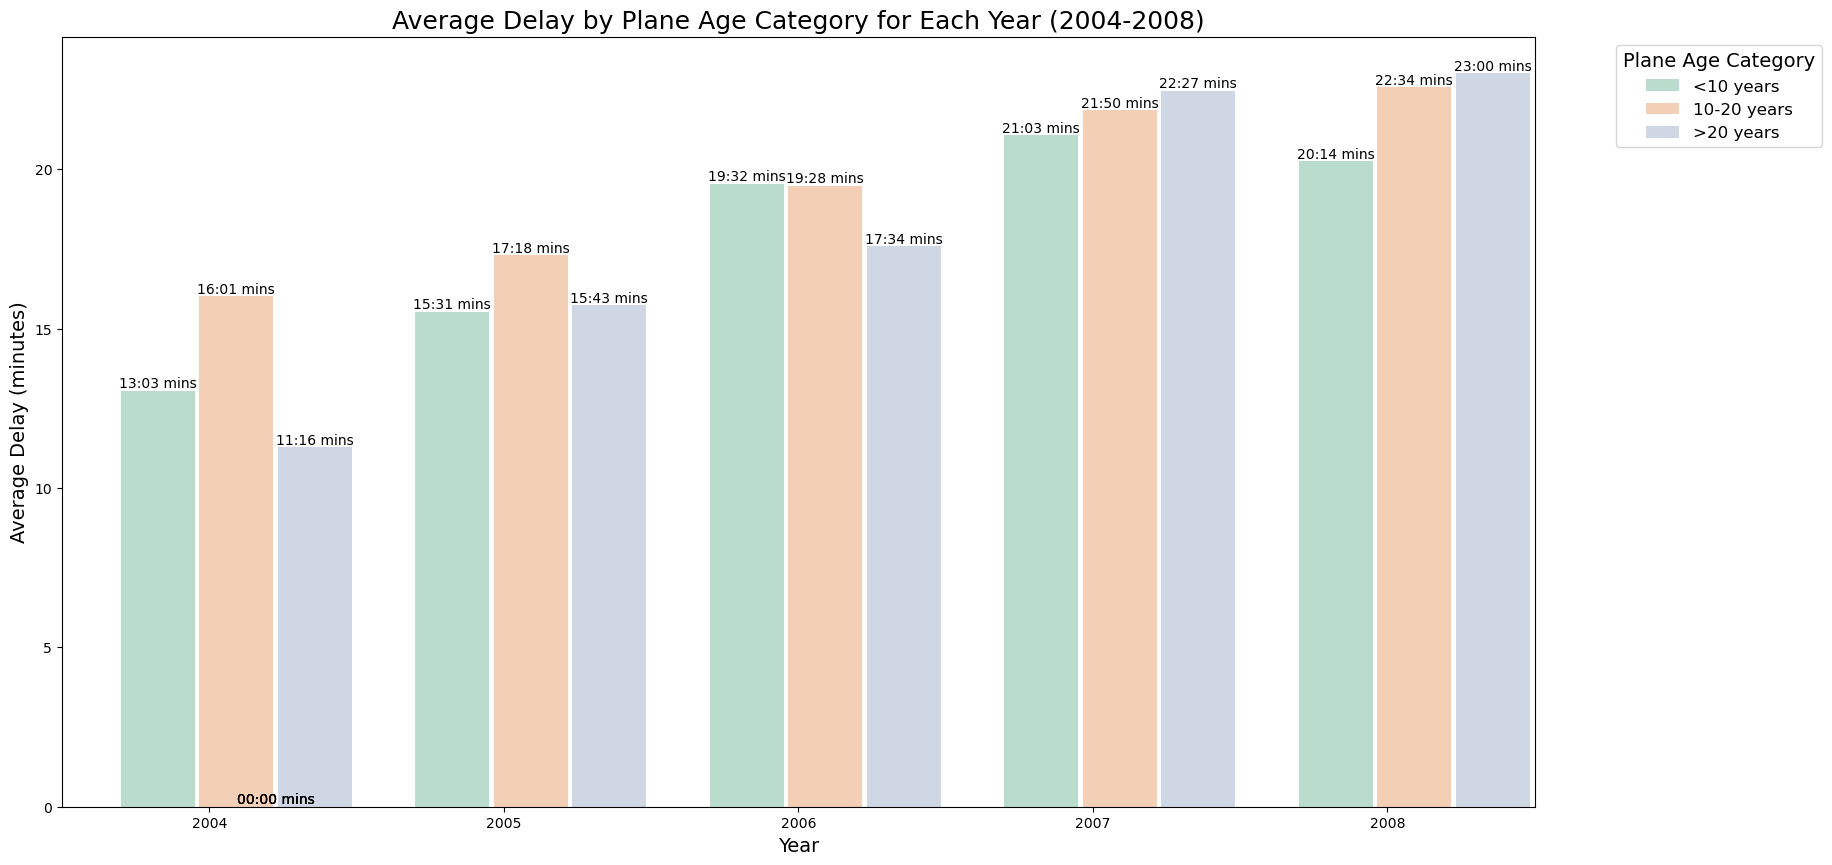

In [73]:
# Categorize plane age into bins
bins = [0, 10, 20, float('inf')]  # Age categories: <10, 10-20, >20
labels = ['<10 years', '10-20 years', '>20 years']
df_all_years_clean[ 'PlaneAgeCategory'] = pd.cut(df_all_years_clean['PlaneAge'], bins=bins, labels=labels)


# Group by Year and Plane Age Category, and calculate the average delay for each combination
avg_delay_by_age_category_year = df_all_years_clean.groupby(["Year", "PlaneAgeCategory"], observed=False)["NetDelay"].mean().reset_index()

# Plot the relationship between plane age category and average delay for each year
plt.figure(figsize=(19, 10))

# Create the bar plot with dodge=True to separate the bars for different categories within each year
ax = sns.barplot(x="Year", y="NetDelay", hue="PlaneAgeCategory", data=avg_delay_by_age_category_year, palette="Pastel2", dodge=True)

# Adjust the bar width and add spacing between the categories within each year
for p in ax.patches:
    # Move the bars by adjusting their positions to create a gap between the plane age categories
    p.set_width(0.25)  # Adjust the width to make the bars smaller and create a gap
    p.set_x(p.get_x() + 0.1)  # Shift the position of each bar to create spacing

# Add exact delay values on top of bars
for p in ax.patches:
    # Convert the net delay (in minutes) to minutes and seconds
    total_seconds = p.get_height() * 60  # Convert to seconds
    minutes = int(total_seconds // 60)  # Get the minutes
    seconds = int(total_seconds % 60)  # Get the seconds
    
    # Annotate the bar with the formatted time (MM:SS)
    ax.annotate(f"{minutes:02}:{seconds:02} mins", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

# Add labels and title
plt.title("Average Delay by Plane Age Category for Each Year (2004-2008)", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average Delay (minutes)", fontsize=14)
plt.legend(title="Plane Age Category", fontsize=12, title_fontsize=14,  bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## End Of Part 2B
---

## Part 2C

### The objective of this question is to utilize any subset of 5 consecutive years and any other supplementary information provided by Harvard Dataverse.
### For each year, the goal is to fit a logistic regression model for the probability of diverted US flights using features like attributes of the departure date, the scheduled departure and arrival times, the coordinates and distance between departure and planned arrival airport, and the carrier information. We will then visualise the coefficients across the selected five years,

### We will reload the years data from the CSV files again using the same code done in part 2A. 
### This is so that we can use the data thats not been tampered with for the logistic regression.

In [98]:
# Reload data from CSV files (prevents data contamination from previous parts)
folder_path = "./dataverse_files"
years = [2004, 2005, 2006, 2007, 2008]  # Define years
file_paths = {year: os.path.join(folder_path, f"{year}.csv") for year in years}


# Load data for all years
data_log = {}
for year, file_path in file_paths.items():
    print(f"Loading {year}...")
    try:
        df = pd.read_csv(file_path, encoding="utf-8", dtype={22: str}, low_memory=False)
    except UnicodeDecodeError:
        print(f"UTF-8 failed for {year}. Retrying with latin1...")
        df = pd.read_csv(file_path, encoding="latin1", dtype={22: str}, low_memory=False)
    
    data_log[year] = df

    print(f"{year} loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
    
print("All files loaded successfully!")


Loading 2004...
2004 loaded: 7,129,270 rows, 29 columns
Loading 2005...
2005 loaded: 7,140,596 rows, 29 columns
Loading 2006...
2006 loaded: 7,141,922 rows, 29 columns
Loading 2007...
2007 loaded: 7,453,215 rows, 29 columns
Loading 2008...
2008 loaded: 2,389,217 rows, 29 columns
All files loaded successfully!


### We will proceed to train a logistic regression model for each year.
### We will define "define" with the selected variables, "target" as the target variable.
### We will also define "numerical_columns" and "categorical_columns" to organize the data preprocessing steps clearly.
### "coefficients" and "years_list" are empty lists created to store the model coefficients and the list of years processed. "all_data" is an empty dataframe created to store the cleaned and encoded data across all years.
### We will use a for loop to process each year's dataset where:### 1. We will extract the necessary columns from each year's dataset and remove rows with missing values using "dropna()", storing the result in "df_year".
### 2. The categorical columns ['UniqueCarrier', 'Origin', 'Dest'] (along with 'Month' and 'DayofMonth') are first converted to categorical type.
### 3. We then apply "LabelEncoder" to transform these categorical values into numeric values for modeling.
### 4. The cleaned and encoded data for each year is appended to the "all_data" dataframe.
### 5. We then split the data into "feat_df" (features) and "target_df" (the target variable "Diverted").
### 6. Using "train_test_split", the data is divided into training and testing sets with a 90:10 ratio (90% train, 10% test), with a fixed random state for reproducibility.
### 7. The input features are standardized using "StandardScaler" to ensure they have mean 0 and standard deviation 1.
### 8. A logistic regression model is trained using "LogisticRegression" with a high maximum iteration value to ensure convergence.
### 9. The predicted probabilities are used to calculate the AUC score for model evaluation.
### 10. The model's coefficients are stored in the "coefficients" list and the corresponding year in "years_list". The coefficient values and AUC score are printed year by year..

In [102]:
# Define the columns required for analysis
features = ["Month", "DayofMonth", "CRSDepTime", "CRSArrTime", "Distance", "UniqueCarrier", "Origin", "Dest"]
target = "Diverted"
cols_needed = features + [target]

numerical_columns = ["Month", "DayofMonth", "CRSDepTime", "CRSArrTime", "Distance"]
categorical_columns = ["UniqueCarrier", "Origin", "Dest"]
    
# Initialize lists for storing results
coefficients = []
years_list = []

# Dataframe to store all processed data
all_data = pd.DataFrame()

# Process each year's dataset
for year in years:
    print(f"Processing {year}...")

    # Get the dataframe for the specific year and keep only required columns and drop missing values
    df_year = data_log[year][cols_needed].dropna() 

    
    # Apply Label Encoding to categorical columns
    df_year[categorical_columns] = df_year[categorical_columns].astype('category')
    encoder = LabelEncoder()
    df_year[categorical_columns] = df_year[categorical_columns].apply(encoder.fit_transform)

    # Append to the combined dataset
    all_data = pd.concat([all_data, df_year], ignore_index=True)

    # Define features and target variable
    feat_df = df_year[features].copy()
    target_df = df_year[target].copy()

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(feat_df, target_df, test_size=0.1, random_state=1)

    # Standardize the features
    scaler = StandardScaler()
    X_train_S = scaler.fit_transform(X_train)
    X_test_S = scaler.transform(X_test)

    
    # Train logistic regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_S, y_train)

    # AUC calculation
    y_prob = model.predict_proba(X_test_S)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    # Store coefficients
    coefficients.append(model.coef_[0])
    years_list.append(year)
    
    # Print coefficients
    print(f"Model trained for {year}")
    print(f"Coefficients:")
    for feature, coef in zip(feat_df.columns, model.coef_[0]):
        print(f"{feature}: {coef:.4f}")
    print(f"AUC Score for {year}: {auc:.3f}\n")
    
  

Processing 2004...
Model trained for 2004
Coefficients:
Month: 0.0573
DayofMonth: 0.0310
CRSDepTime: -0.0494
CRSArrTime: 0.1276
Distance: 0.2528
UniqueCarrier: 0.0109
Origin: -0.0060
Dest: -0.0261
AUC Score for 2004: 0.615

Processing 2005...
Model trained for 2005
Coefficients:
Month: -0.0480
DayofMonth: 0.0158
CRSDepTime: -0.0639
CRSArrTime: 0.1256
Distance: 0.2667
UniqueCarrier: -0.0202
Origin: -0.0188
Dest: -0.0984
AUC Score for 2005: 0.620

Processing 2006...
Model trained for 2006
Coefficients:
Month: -0.0059
DayofMonth: 0.0331
CRSDepTime: -0.0784
CRSArrTime: 0.1350
Distance: 0.3313
UniqueCarrier: 0.0177
Origin: -0.0473
Dest: -0.0460
AUC Score for 2006: 0.626

Processing 2007...
Model trained for 2007
Coefficients:
Month: -0.0152
DayofMonth: 0.0544
CRSDepTime: -0.1665
CRSArrTime: 0.2186
Distance: 0.2794
UniqueCarrier: -0.0686
Origin: -0.0136
Dest: -0.1210
AUC Score for 2007: 0.638

Processing 2008...
Model trained for 2008
Coefficients:
Month: -0.0846
DayofMonth: -0.1240
CRSDepTi

### We will now proceed visualize how the feature coefficients change over time.
### We convert the stored list of coefficient arrays into a DataFrame called "coeffs_df", using the feature column names from "feat_df" as headers.
### The list of years stored in "years_list" is converted into a DataFrame named "years_df".
### These two DataFrames are combined using "pd.concat()" to create a single DataFrame called "combined_df" that contains both the year and the corresponding model coefficients.


### We ensure there are no duplicate columns (such as "Year") using "loc[:, ~combined_df.columns.duplicated()]"
### We then set "Year" as the index of the combined DataFrame to use it as the x-axis in the plot.
### A bar plot is generated to show the coefficients of each feature across all years.

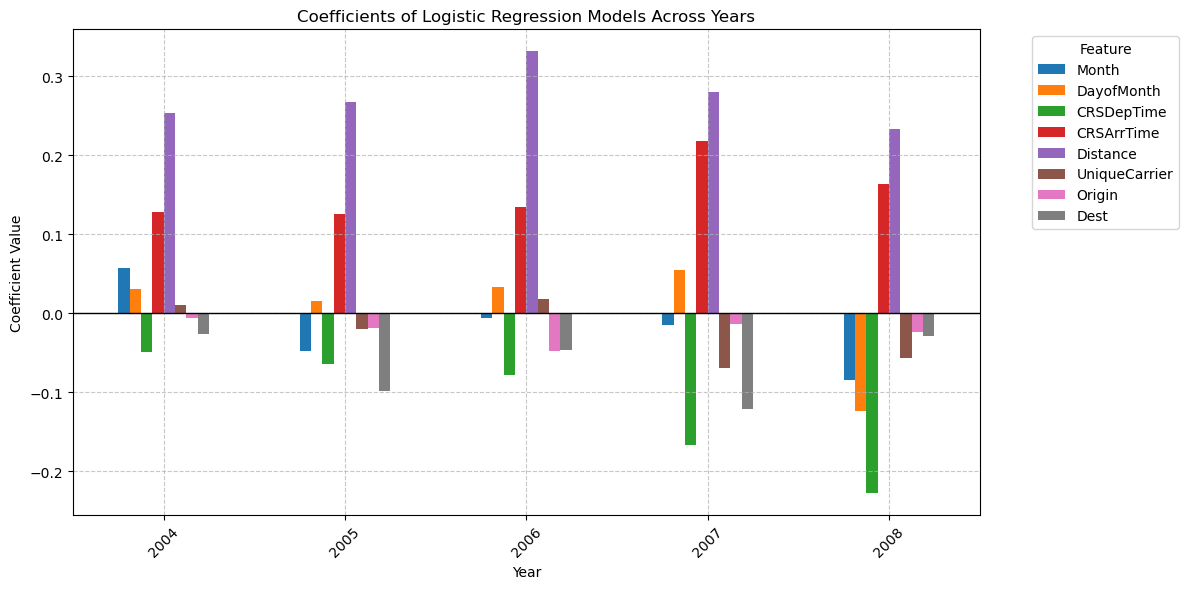

In [104]:
# Convert coefficients to a DataFrame
coeffs_df = pd.DataFrame(coefficients, columns=feat_df.columns)

# Convert years to a DataFrame
years_df = pd.DataFrame({'Year': years_list})

# Combine DataFrames and remove duplicate 'Year' column
combined_df = pd.concat([years_df, coeffs_df], axis=1)
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]

# Set 'Year' as index for plotting
combined_df.set_index('Year', inplace=True)

# Ensure we only plot numeric values
plt.figure(figsize=(12, 6))

# Plot with corrected indexing
ax = combined_df.plot(kind='bar', ax=plt.gca())

# Fix legend issue by ensuring labels are set
handles, labels = ax.get_legend_handles_labels()
if not labels:
    print("Warning: No labels found for legend. Double-check feature names.")

# Add grid lines for better readability
plt.grid(True, linestyle="--", alpha=0.7)

# Add a reference horizontal line at y=0
plt.axhline(0, color="black", linewidth=1)

plt.title('Coefficients of Logistic Regression Models Across Years')
plt.xlabel('Year')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)

# Adjust legend positioning
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### We will now build a general logistic regression model using the combined dataset from all years and plot a single ROC curve.
### We extract the features into "X_all" by dropping the target column "Diverted" from "all_data".
### The target variable "Diverted" is stored separately in "y_all".
### We perform a train-test split using an 80:20 ratio to prepare the data for model evaluation.
### The training and testing feature sets are standardized using "StandardScaler" to ensure all features are on a similar scale.
### We train a logistic regression model on the scaled training data using "LogisticRegression" with a high maximum iteration limit for convergence.
### Using "RocCurveDisplay.from_estimator()", we plot the ROC curve to visualize the model's performance on the test data.

<Figure size 640x480 with 0 Axes>

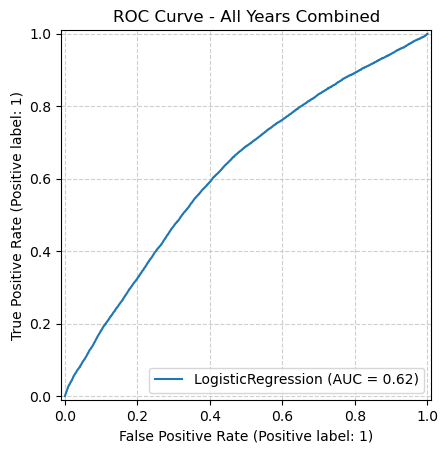

In [92]:
# General ROC curve using all years combined

# Feature + target
feat_df_all = all_data.drop(columns=['Diverted'])  # remove 'Diverted' 
target_df_all = all_data['Diverted']

# Train-test split
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(feat_df_all, target_df_all, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_all_S = scaler.fit_transform(X_train_all)
X_test_all_S = scaler.transform(X_test_all)

# Fit the model
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train_all_S, y_train_all)

# Plot the ROC graph
plt.figure()
RocCurveDisplay.from_estimator(model_all, X_test_all_S, y_test_all)
plt.title("ROC Curve - All Years Combined")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


## End Of Part 2C

---

# This is the end of Part 2 of the coursework.

---